# 🛒 Project 1 — Supermarket Sales Analysis
**Goal:** Analyze 2000 supermarket transactions to find sales trends, top products, customer behavior, and business insights.

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set chart style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📂 Step 2: Load the Dataset

In [2]:
# Load the CSV file — make sure supermarket_sales.csv is in the same folder
df = pd.read_csv('supermarket_sales.csv')

print('✅ Dataset loaded!')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'Columns: {df.columns.tolist()}')

✅ Dataset loaded!
Rows: 2000, Columns: 14
Columns: ['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender', 'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date', 'Time', 'Payment', 'Rating']


## 🔍 Step 3: Explore the Data

In [3]:
# See first 5 rows
df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [4]:
# Check data types and missing values
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
Invoice_ID           str
Branch               str
City                 str
Customer_Type        str
Gender               str
Product_Line         str
Unit_Price       float64
Quantity           int64
Tax              float64
Total            float64
Date                 str
Time                 str
Payment              str
Rating           float64
dtype: object

Missing Values:
Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64


In [5]:
# Basic statistics
df.describe()

,Unit_Price,Quantity,Tax,Total,Rating
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000
mean,55.258490,5.0330,5.512745,259.640345,6.957600
std,25.813536,2.6087,2.582829,138.930861,1.730534
min,10.010000,1.0000,1.000000,20.370000,4.000000
25%,33.615000,3.0000,3.317500,137.872500,5.400000
50%,55.610000,5.0000,5.440000,258.040000,6.950000
75%,77.500000,7.0000,7.742500,386.937500,8.400000
max,99.920000,9.0000,10.000000,499.910000,10.000000


## 🧹 Step 4: Clean the Data

In [6]:
# Convert Date column to proper date format
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful columns from Date and Time
df['Month'] = df['Date'].dt.month_name()
df['Day']   = df['Date'].dt.day_name()
df['Hour']  = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

print('✅ Date cleaned and new columns added!')
df[['Date', 'Month', 'Day', 'Hour']].head()

✅ Date cleaned and new columns added!


,Date,Month,Day,Hour
0,2023-08-08,August,Tuesday,18
1,2023-02-09,February,Thursday,18
2,2023-08-24,August,Thursday,16
3,2023-02-09,February,Thursday,11
4,2023-07-04,July,Tuesday,8


## 📊 Step 5: Analysis + Visualizations

---
### 📌 Chart 1: Sales by Branch (Which branch earns the most?)

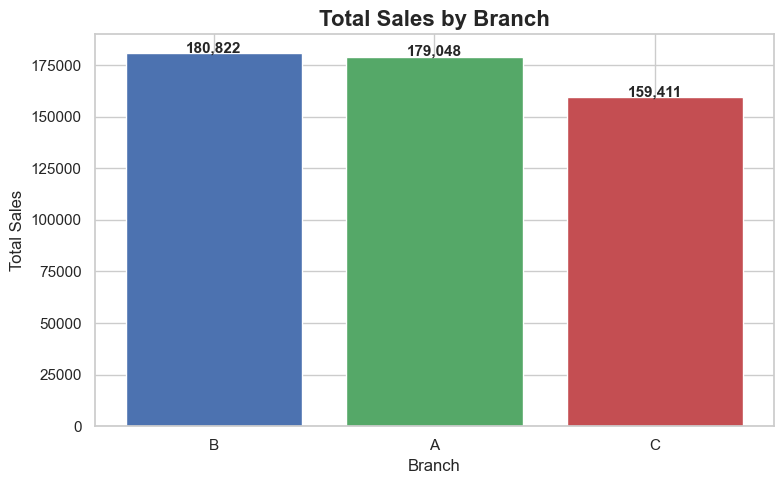


🏆 Best Branch: B with total sales of 180,822


In [7]:
branch_sales = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(branch_sales.index, branch_sales.values, color=['#4C72B0','#55A868','#C44E52'])
plt.title('Total Sales by Branch', fontsize=16, fontweight='bold')
plt.xlabel('Branch', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Add value labels on bars
for bar, val in zip(bars, branch_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_branch_sales.png', dpi=150)
plt.show()
print(f'\n🏆 Best Branch: {branch_sales.idxmax()} with total sales of {branch_sales.max():,.0f}')

### 📌 Chart 2: Sales by Product Line (Which product sells the most?)

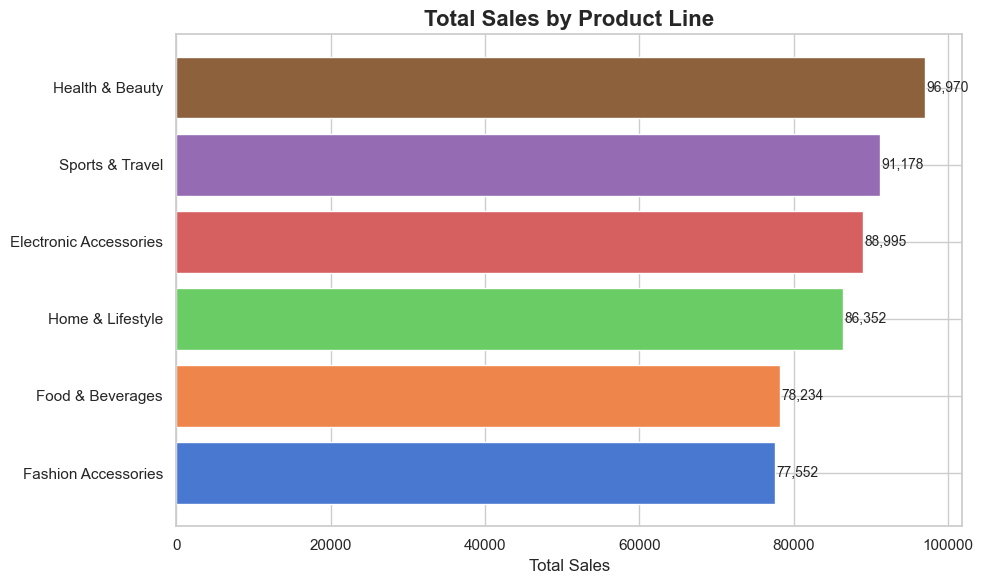


🏆 Best Product: Health & Beauty
📉 Lowest Product: Fashion Accessories


In [8]:
product_sales = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(product_sales.index, product_sales.values, color=sns.color_palette('muted', len(product_sales)))
plt.title('Total Sales by Product Line', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales', fontsize=12)

for bar, val in zip(bars, product_sales.values):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_product_sales.png', dpi=150)
plt.show()
print(f'\n🏆 Best Product: {product_sales.idxmax()}')
print(f'📉 Lowest Product: {product_sales.idxmin()}')

### 📌 Chart 3: Sales by Gender (Who spends more — Male or Female?)

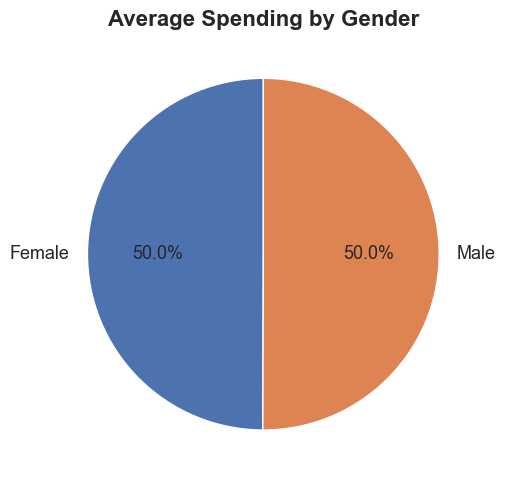


👨 Male avg spending: 259.88
👩 Female avg spending: 259.41


In [9]:
gender_sales = df.groupby('Gender')['Total'].mean()

plt.figure(figsize=(7, 5))
plt.pie(gender_sales.values, labels=gender_sales.index, autopct='%1.1f%%',
        colors=['#4C72B0','#DD8452'], startangle=90,
        textprops={'fontsize': 13})
plt.title('Average Spending by Gender', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_gender_spending.png', dpi=150)
plt.show()
print(f'\n👨 Male avg spending: {gender_sales["Male"]:,.2f}')
print(f'👩 Female avg spending: {gender_sales["Female"]:,.2f}')

### 📌 Chart 4: Busiest Hours (When do most customers shop?)

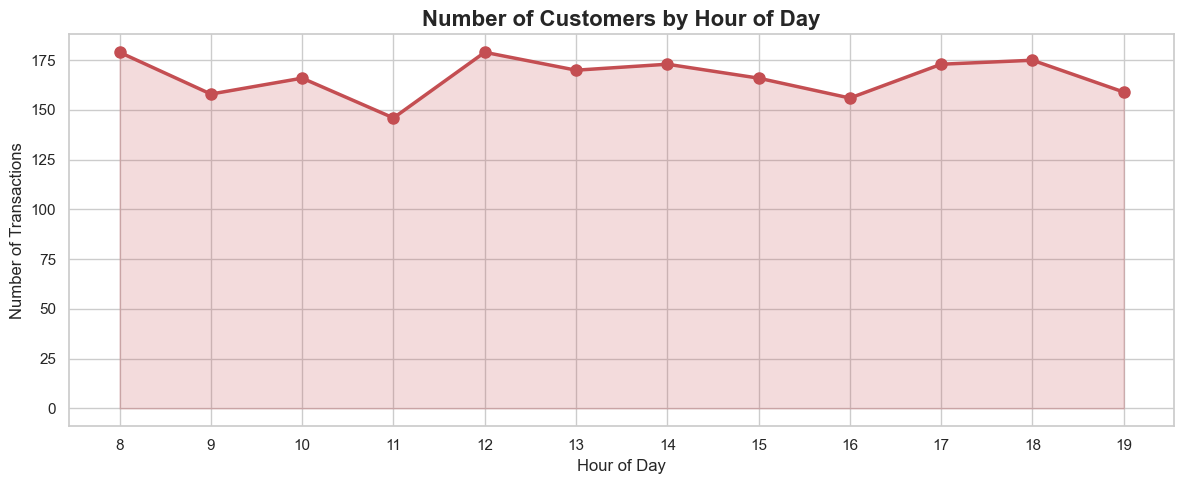


⏰ Busiest Hour: 8:00 with 179 transactions


In [10]:
hourly = df.groupby('Hour')['Invoice_ID'].count()

plt.figure(figsize=(12, 5))
plt.plot(hourly.index, hourly.values, marker='o', color='#C44E52', linewidth=2.5, markersize=8)
plt.fill_between(hourly.index, hourly.values, alpha=0.2, color='#C44E52')
plt.title('Number of Customers by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(hourly.index)
plt.tight_layout()
plt.savefig('chart4_busiest_hours.png', dpi=150)
plt.show()
print(f'\n⏰ Busiest Hour: {hourly.idxmax()}:00 with {hourly.max()} transactions')

### 📌 Chart 5: Payment Method Preference

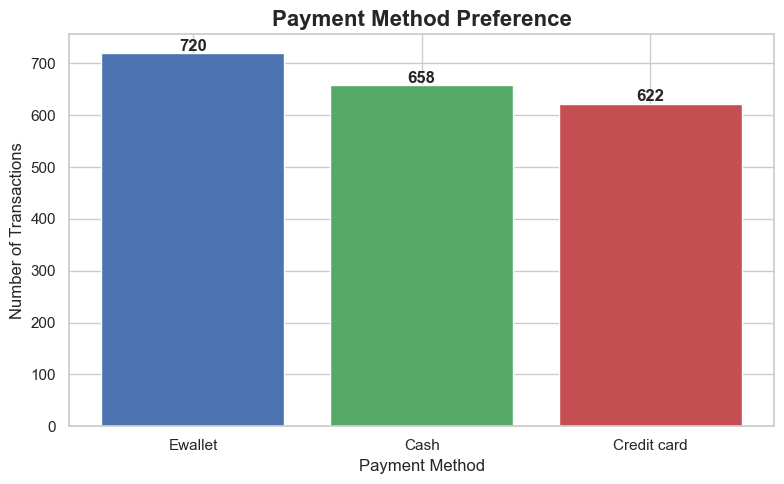


💳 Most Used: Ewallet (720 times)


In [11]:
payment = df['Payment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(payment.index, payment.values, color=['#4C72B0','#55A868','#C44E52'])
plt.title('Payment Method Preference', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

for bar, val in zip(bars, payment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_payment_method.png', dpi=150)
plt.show()
print(f'\n💳 Most Used: {payment.idxmax()} ({payment.max()} times)')

### 📌 Chart 6: Customer Rating Distribution

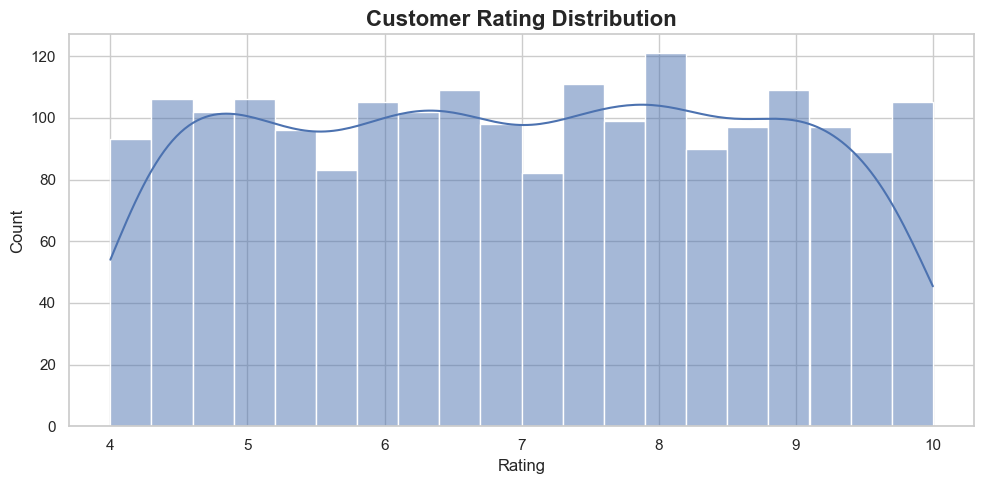


⭐ Average Rating: 6.96
⭐ Highest Rating: 10.0
⭐ Lowest Rating: 4.0


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=20, kde=True, color='#4C72B0')
plt.title('Customer Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_ratings.png', dpi=150)
plt.show()
print(f'\n⭐ Average Rating: {df["Rating"].mean():.2f}')
print(f'⭐ Highest Rating: {df["Rating"].max()}')
print(f'⭐ Lowest Rating: {df["Rating"].min()}')

## 💡 Step 6: Business Insights Summary

In [13]:
print('=' * 55)
print('       🛒 SUPERMARKET SALES ANALYSIS REPORT')
print('=' * 55)

print(f'\n📊 OVERVIEW:')
print(f'   Total Transactions : {len(df):,}')
print(f'   Total Revenue      : {df["Total"].sum():,.2f}')
print(f'   Average Sale Value : {df["Total"].mean():,.2f}')
print(f'   Average Rating     : {df["Rating"].mean():.2f} / 10')

print(f'\n🏆 TOP PERFORMERS:')
print(f'   Best Branch        : {df.groupby("Branch")["Total"].sum().idxmax()}')
print(f'   Best Product Line  : {df.groupby("Product_Line")["Total"].sum().idxmax()}')
print(f'   Busiest Hour       : {df.groupby("Hour")["Total"].count().idxmax()}:00')
print(f'   Top Payment Method : {df["Payment"].value_counts().idxmax()}')

print(f'\n💡 KEY BUSINESS INSIGHTS:')
print('   1. Focus marketing on the best-performing branch')
print('   2. Stock more of the top product line')
print('   3. Schedule more staff during peak hours')
print('   4. Promote the most preferred payment method')
print('   5. Investigate lowest-rated products for improvement')

print('\n' + '=' * 55)

       🛒 SUPERMARKET SALES ANALYSIS REPORT

📊 OVERVIEW:
   Total Transactions : 2,000
   Total Revenue      : 519,280.69
   Average Sale Value : 259.64
   Average Rating     : 6.96 / 10

🏆 TOP PERFORMERS:
   Best Branch        : B
   Best Product Line  : Health & Beauty
   Busiest Hour       : 8:00
   Top Payment Method : Ewallet

💡 KEY BUSINESS INSIGHTS:
   1. Focus marketing on the best-performing branch
   2. Stock more of the top product line
   3. Schedule more staff during peak hours
   4. Promote the most preferred payment method
   5. Investigate lowest-rated products for improvement



## ✅ Project 1 Complete!
**You have successfully:**
- Loaded and explored 2000 sales records
- Cleaned and transformed the data
- Created 6 professional visualizations
- Generated key business insights

**Charts saved:** chart1 to chart6 as PNG files in your folder.

---
➡️ Next: Open `project2_house_prices.ipynb` for Project 2!